In [1]:
#  PHASE 2 — LayerRouter + FeatureEngineer                       
#  Reads Phase 1 outputs, builds 5-layer enriched views          

!pip install scikit-learn pandas numpy matplotlib seaborn scipy -q

import os, pickle, warnings, json
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import matplotlib.pyplot  as plt
import matplotlib.patches as mpatches
import seaborn            as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#f8f9fa',
    'axes.grid'        : True,
    'grid.alpha'       : 0.35,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 11,
    'figure.dpi'       : 120,
})

LAYER_COLORS = {
    'physical'    : '#2196F3',
    'network'     : '#FF9800',
    'control'     : '#4CAF50',
    'supervisory' : '#9C27B0',
    'process'     : '#F44336',
}

# ── Phase 1 output path ──────────────────────────────────────────
P1 = '/kaggle/input/notebooks/jaytalwar2005/ctmas-phase1/processed'
OUT = '/kaggle/working/'

for d in [f'{OUT}/figures', f'{OUT}/processed']:
    os.makedirs(d, exist_ok=True)

# ── Verify Phase 1 files exist ───────────────────────────────────
required = [
    'swat_clean.csv', 'swat_scaled.csv', 'layer_map.json',
    'scaler.pkl', 'layer_stats.pkl', 'phase1_config.json',
    'sensor_cols.json'
]
print('Verifying Phase 1 outputs:')
all_ok = True
for f in required:
    path   = f'{P1}/{f}'
    exists = os.path.exists(path)
    size   = os.path.getsize(path)/1024**2 if exists else 0
    status = 'Yes' if exists else 'No MISSING'
    print(f'  {status}  {f:<35}  {size:6.1f} MB')
    if not exists:
        all_ok = False

print(f'\n  All files present: {"YES" if all_ok else "NO — check paths"}')

Verifying Phase 1 outputs:
  Yes  swat_clean.csv                        281.4 MB
  Yes  swat_scaled.csv                       544.2 MB
  Yes  layer_map.json                          0.0 MB
  Yes  scaler.pkl                              0.0 MB
  Yes  layer_stats.pkl                         0.0 MB
  Yes  phase1_config.json                      0.0 MB
  Yes  sensor_cols.json                        0.0 MB

  All files present: YES


In [2]:
#   CELL 2 — Load all Phase 1 outputs                             
print('Loading Phase 1 outputs...')

# Master cleaned dataset
df = pd.read_csv(f'{P1}/swat_clean.csv', low_memory=False)
print(f'  Yes swat_clean.csv     → {df.shape[0]:,} rows × {df.shape[1]} cols')

# Scaled dataset
df_scaled = pd.read_csv(f'{P1}/swat_scaled.csv', low_memory=False)
print(f'  Yes swat_scaled.csv    → {df_scaled.shape[0]:,} rows × {df_scaled.shape[1]} cols')

# Layer map
with open(f'{P1}/layer_map.json') as f:
    LAYER_MAP = json.load(f)
print(f'  Yes layer_map.json     → {len(LAYER_MAP)} layers')

# Sensor columns
with open(f'{P1}/sensor_cols.json') as f:
    SENSOR_COLS = json.load(f)
print(f'  Yes sensor_cols.json   → {len(SENSOR_COLS)} sensors')

# Phase 1 config
with open(f'{P1}/phase1_config.json') as f:
    P1_CONFIG = json.load(f)
print(f'  Yes phase1_config.json → loaded')

# Layer stats
with open(f'{P1}/layer_stats.pkl', 'rb') as f:
    layer_stats = pickle.load(f)
print(f'  Yes layer_stats.pkl    → loaded')

# Scaler
with open(f'{P1}/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)
print(f'  Yes scaler.pkl         → loaded')

# Timestamp column
TIME_COL = P1_CONFIG.get('time_col', 'Timestamp')
if TIME_COL and TIME_COL in df.columns:
    df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors='coerce')

print(f'\n All Phase 1 data loaded')
print(f'  Total rows    : {len(df):,}')
print(f'  Normal rows   : {(df["binary_label"]==0).sum():,}')
print(f'  Attack rows   : {(df["binary_label"]==1).sum():,}')
print(f'  Layers        : {list(LAYER_MAP.keys())}')

Loading Phase 1 outputs...
  Yes swat_clean.csv     → 944,919 rows × 55 cols
  Yes swat_scaled.csv    → 944,919 rows × 55 cols
  Yes layer_map.json     → 5 layers
  Yes sensor_cols.json   → 51 sensors
  Yes phase1_config.json → loaded
  Yes layer_stats.pkl    → loaded
  Yes scaler.pkl         → loaded

 All Phase 1 data loaded
  Total rows    : 944,919
  Normal rows   : 890,298
  Attack rows   : 54,621
  Layers        : ['physical', 'network', 'control', 'supervisory', 'process']


In [3]:
#   CELL 3 — LayerRouter                                          
#   Structural backbone: slices master df into 5 layer views      

class LayerRouter:
    """
    Routes SWaT data into 5 independent CPS layer views.
    Each view contains only the sensors relevant to that layer
    plus the binary_label for supervised training.
    """

    def __init__(self, df, layer_map, time_col=None):
        self.df        = df
        self.layer_map = layer_map
        self.time_col  = time_col
        self.meta_cols = ['binary_label', 'label', 'source']
        if time_col and time_col in df.columns:
            self.meta_cols = [time_col] + self.meta_cols

    def get_layer(self, layer_name):
        """Return dataframe containing only that layer's features + labels."""
        if layer_name not in self.layer_map:
            raise ValueError(f'Layer "{layer_name}" not in layer_map')
        feats  = list(dict.fromkeys(self.layer_map[layer_name]))
        feats  = [f for f in feats if f in self.df.columns]
        keep   = feats + [m for m in self.meta_cols
                          if m in self.df.columns and m not in feats]
        return self.df[keep].copy()

    def get_all_layers(self):
        """Return dict of {layer_name: dataframe} for all 5 layers."""
        return {layer: self.get_layer(layer)
                for layer in self.layer_map}

    def get_train_test_split(self, layer_name, test_ratio=0.2):
        """
        Split layer data into train/test.
        Train = normal operation only (for unsupervised models).
        Test  = attack data (for evaluation).
        """
        layer_df = self.get_layer(layer_name)
        feats    = [c for c in layer_df.columns
                    if c not in ['binary_label', 'label',
                                 'source', self.time_col]]

        # Train: normal data only (for VAE, unsupervised)
        train_df = layer_df[layer_df['binary_label'] == 0].copy()

        # Test: last 20% of data (contains attacks)
        n_test   = int(len(layer_df) * test_ratio)
        test_df  = layer_df.iloc[-n_test:].copy()

        return train_df, test_df, feats

    def summary(self):
        print()
        print('  LAYER ROUTER SUMMARY')
        print()
        for layer in self.layer_map:
            ldf   = self.get_layer(layer)
            feats = [c for c in ldf.columns
                     if c not in ['binary_label', 'label',
                                  'source', self.time_col]]
            atk   = (ldf['binary_label']==1).sum()
            print(f'\n  {layer.upper()} LAYER')
            print(f'    Features : {len(feats)}')
            print(f'    Rows     : {len(ldf):,}')
            print(f'    Attacks  : {atk:,} ({atk/len(ldf)*100:.1f}%)')
            print(f'    Sensors  : {feats}')

# ── Instantiate ──────────────────────────────────────────────────
router = LayerRouter(df, LAYER_MAP, TIME_COL)
router.summary()

print('\n LayerRouter built and verified')


  LAYER ROUTER SUMMARY


  PHYSICAL LAYER
    Features : 25
    Rows     : 944,919
    Attacks  : 54,621 (5.8%)
    Sensors  : ['FIT101', 'LIT101', 'AIT201', 'AIT202', 'AIT203', 'FIT201', 'DPIT301', 'FIT301', 'LIT301', 'AIT401', 'AIT402', 'FIT401', 'LIT401', 'AIT501', 'AIT502', 'AIT503', 'AIT504', 'FIT501', 'FIT502', 'FIT503', 'FIT504', 'PIT501', 'PIT502', 'PIT503', 'FIT601']

  NETWORK LAYER
    Features : 9
    Rows     : 944,919
    Attacks  : 54,621 (5.8%)
    Sensors  : ['FIT101', 'FIT201', 'FIT301', 'FIT401', 'FIT501', 'FIT601', 'LIT101', 'LIT301', 'LIT401']

  CONTROL LAYER
    Features : 26
    Rows     : 944,919
    Attacks  : 54,621 (5.8%)
    Sensors  : ['MV101', 'P101', 'P102', 'MV201', 'P201', 'P202', 'P203', 'P204', 'P205', 'P206', 'MV301', 'MV302', 'MV303', 'MV304', 'P301', 'P302', 'P401', 'P402', 'P403', 'P404', 'UV401', 'P501', 'P502', 'P601', 'P602', 'P603']

  SUPERVISORY LAYER
    Features : 15
    Rows     : 944,919
    Attacks  : 54,621 (5.8%)
    Sensors  : ['LI

In [4]:
#  CELL 4 — FeatureEngineer                                      
#  Adds derived features to each layer view                      
#  This is what separates layer views from just column splits    


class FeatureEngineer:
    """
    Creates domain-specific derived features for each CPS layer.

    Physical    → rolling mean, rolling std, z-score per sensor
    Network     → inter-sensor timing deltas (diff between readings)
    Control     → actuator state change flags (0→1, 1→0, 1→2)
    Supervisory → setpoint deviation (distance from mean setpoint)
    Process     → cross-sensor mass balance residuals
    """

    def __init__(self, window=10):
        self.window = window   # rolling window size

    def engineer_physical(self, layer_df):
        """Rolling stats for each physical sensor."""
        df_ = layer_df.copy()
        sensor_cols = self._get_sensor_cols(df_)

        for col in sensor_cols:
            # Rolling mean — captures slow drift attacks
            df_[f'{col}_rmean'] = (df_[col]
                                   .rolling(self.window, min_periods=1)
                                   .mean())
            # Rolling std — captures volatility increase during attacks
            df_[f'{col}_rstd'] = (df_[col]
                                  .rolling(self.window, min_periods=1)
                                  .std()
                                  .fillna(0))
            # Z-score — standardised deviation from local mean
            mean_ = df_[f'{col}_rmean']
            std_  = df_[f'{col}_rstd'].replace(0, 1e-9)
            df_[f'{col}_zscore'] = (df_[col] - mean_) / std_

        print(f'  Physical: {len(sensor_cols)} sensors → '
              f'{len(sensor_cols)*3} new features added')
        return df_

    def engineer_network(self, layer_df):
        """Timing deltas — difference between consecutive readings."""
        df_ = layer_df.copy()
        sensor_cols = self._get_sensor_cols(df_)

        for col in sensor_cols:
            # First-order diff — rate of change
            df_[f'{col}_diff1'] = df_[col].diff().fillna(0)
            # Second-order diff — acceleration (catches sudden changes)
            df_[f'{col}_diff2'] = df_[f'{col}_diff1'].diff().fillna(0)
            # Absolute rate of change
            df_[f'{col}_abs_diff'] = df_[f'{col}_diff1'].abs()

        print(f'  Network: {len(sensor_cols)} sensors → '
              f'{len(sensor_cols)*3} new features added')
        return df_

    def engineer_control(self, layer_df):
        """Actuator state change detection."""
        df_ = layer_df.copy()
        sensor_cols = self._get_sensor_cols(df_)

        for col in sensor_cols:
            prev = df_[col].shift(1).fillna(df_[col].iloc[0])
            # State changed flag
            df_[f'{col}_changed'] = (df_[col] != prev).astype(int)
            # Direction of change: +1 = opened/increased, -1 = closed/decreased
            df_[f'{col}_direction'] = np.sign(df_[col] - prev)
            # Cumulative changes — repeated toggling = suspicious
            df_[f'{col}_cum_changes'] = (df_[f'{col}_changed']
                                          .rolling(self.window, min_periods=1)
                                          .sum())

        print(f'  Control: {len(sensor_cols)} sensors → '
              f'{len(sensor_cols)*3} new features added')
        return df_

    def engineer_supervisory(self, layer_df):
        """Setpoint deviation features."""
        df_ = layer_df.copy()
        sensor_cols = self._get_sensor_cols(df_)

        for col in sensor_cols:
            # Compute setpoint as long-window rolling mean of normal data
            long_mean = df_[col].rolling(500, min_periods=1).mean()
            # Deviation from setpoint
            df_[f'{col}_setpoint_dev'] = (df_[col] - long_mean).abs()
            # Normalised deviation
            std_ = df_[col].std()
            df_[f'{col}_setpoint_dev_norm'] = (
                df_[f'{col}_setpoint_dev'] / (std_ + 1e-9))
            # Alarm flag: deviation > 2 std
            df_[f'{col}_alarm'] = (
                df_[f'{col}_setpoint_dev_norm'] > 2).astype(int)

        print(f'  Supervisory: {len(sensor_cols)} sensors → '
              f'{len(sensor_cols)*3} new features added')
        return df_

    def engineer_process(self, layer_df):
        """Cross-sensor mass balance and physics invariants."""
        df_ = layer_df.copy()
        sensor_cols = self._get_sensor_cols(df_)
        flow_cols   = [c for c in sensor_cols if 'FIT' in c]
        level_cols  = [c for c in sensor_cols if 'LIT' in c]

        # Mass balance residual: total flow in - total flow out
        # Should be approximately zero in normal operation
        if len(flow_cols) >= 2:
            flow_in  = df_[flow_cols[0]]   # Stage 1 inlet
            flow_out = df_[flow_cols[-1]]  # Last stage outlet
            df_['mass_balance_residual'] = (flow_in - flow_out).abs()
            df_['mass_balance_ratio']    = (
                flow_in / (flow_out + 1e-9)).clip(0, 10)

        # Level rate of change (dV/dt) for each tank
        for col in level_cols:
            df_[f'{col}_dvdt'] = df_[col].diff().fillna(0)

        # Cross-sensor correlation deviation
        if len(flow_cols) >= 3:
            # Rolling correlation between consecutive flow stages
            for i in range(len(flow_cols) - 1):
                c1 = flow_cols[i]
                c2 = flow_cols[i+1]
                corr_col = f'{c1}_{c2}_corr_dev'
                rolling_corr = (df_[c1].rolling(self.window, min_periods=2)
                                .corr(df_[c2])
                                .fillna(0))
                df_[corr_col] = (1 - rolling_corr.abs())  # 0=normal, 1=anomaly

        new_cols = [c for c in df_.columns if c not in layer_df.columns]
        print(f'  Process: {len(sensor_cols)} sensors → '
              f'{len(new_cols)} new features added')
        return df_

    def engineer_layer(self, layer_name, layer_df):
        """Route to correct engineering function by layer name."""
        fn_map = {
            'physical'    : self.engineer_physical,
            'network'     : self.engineer_network,
            'control'     : self.engineer_control,
            'supervisory' : self.engineer_supervisory,
            'process'     : self.engineer_process,
        }
        if layer_name not in fn_map:
            raise ValueError(f'No engineer for layer "{layer_name}"')
        return fn_map[layer_name](layer_df)

    def _get_sensor_cols(self, df_):
        exclude = {'binary_label', 'label', 'source', 'Timestamp'}
        # also exclude any already-derived columns
        return [c for c in df_.columns
                if c not in exclude
                and not any(c.endswith(s) for s in [
                    '_rmean', '_rstd', '_zscore',
                    '_diff1', '_diff2', '_abs_diff',
                    '_changed', '_direction', '_cum_changes',
                    '_setpoint_dev', '_setpoint_dev_norm', '_alarm',
                    '_dvdt', '_corr_dev'
                ])]

# ── Instantiate ──────────────────────────────────────────────────
engineer = FeatureEngineer(window=10)
print(' FeatureEngineer built')
print(f'  Rolling window size : {engineer.window}')

 FeatureEngineer built
  Rolling window size : 10


In [5]:
#  CELL 5 — Build all 5 engineered layer views                   


print('Building engineered layer views...')
print()

engineered_layers = {}
layer_feature_counts = {}

for layer in LAYER_MAP.keys():
    print(f'\nProcessing {layer.upper()} layer...')

    # Step 1: get raw layer view from router
    raw_view = router.get_layer(layer)

    # Step 2: apply feature engineering
    eng_view = engineer.engineer_layer(layer, raw_view)

    # Step 3: fill any NaN created by rolling/diff operations
    eng_cols = [c for c in eng_view.columns
                if c not in ['binary_label', 'label', 'source', TIME_COL]]
    eng_view[eng_cols] = (eng_view[eng_cols]
                          .fillna(method='ffill')
                          .fillna(method='bfill')
                          .fillna(0))

    engineered_layers[layer] = eng_view

    orig_feats = len(LAYER_MAP[layer])
    new_feats  = len(eng_cols) - orig_feats
    total_feats = len(eng_cols)

    layer_feature_counts[layer] = {
        'original' : orig_feats,
        'derived'  : new_feats,
        'total'    : total_feats,
    }

    print(f'  Original features : {orig_feats}')
    print(f'  Derived features  : {new_feats}')
    print(f'  Total features    : {total_feats}')
    print(f'  Shape             : {eng_view.shape}')

print()
print('  ENGINEERED LAYER SUMMARY')
print()
for layer, counts in layer_feature_counts.items():
    print(f"  {layer:<15} "
          f"orig={counts['original']:>3}  "
          f"derived={counts['derived']:>4}  "
          f"total={counts['total']:>4}")

print(f'\n All 5 layers engineered successfully')

Building engineered layer views...


Processing PHYSICAL layer...
  Physical: 25 sensors → 75 new features added
  Original features : 25
  Derived features  : 75
  Total features    : 100
  Shape             : (944919, 104)

Processing NETWORK layer...
  Network: 9 sensors → 27 new features added
  Original features : 9
  Derived features  : 27
  Total features    : 36
  Shape             : (944919, 40)

Processing CONTROL layer...
  Control: 26 sensors → 78 new features added
  Original features : 26
  Derived features  : 78
  Total features    : 104
  Shape             : (944919, 108)

Processing SUPERVISORY layer...
  Supervisory: 15 sensors → 45 new features added
  Original features : 15
  Derived features  : 45
  Total features    : 60
  Shape             : (944919, 64)

Processing PROCESS layer...
  Process: 17 sensors → 13 new features added
  Original features : 17
  Derived features  : 13
  Total features    : 30
  Shape             : (944919, 34)

  ENGINEERED LAYER SUMMARY

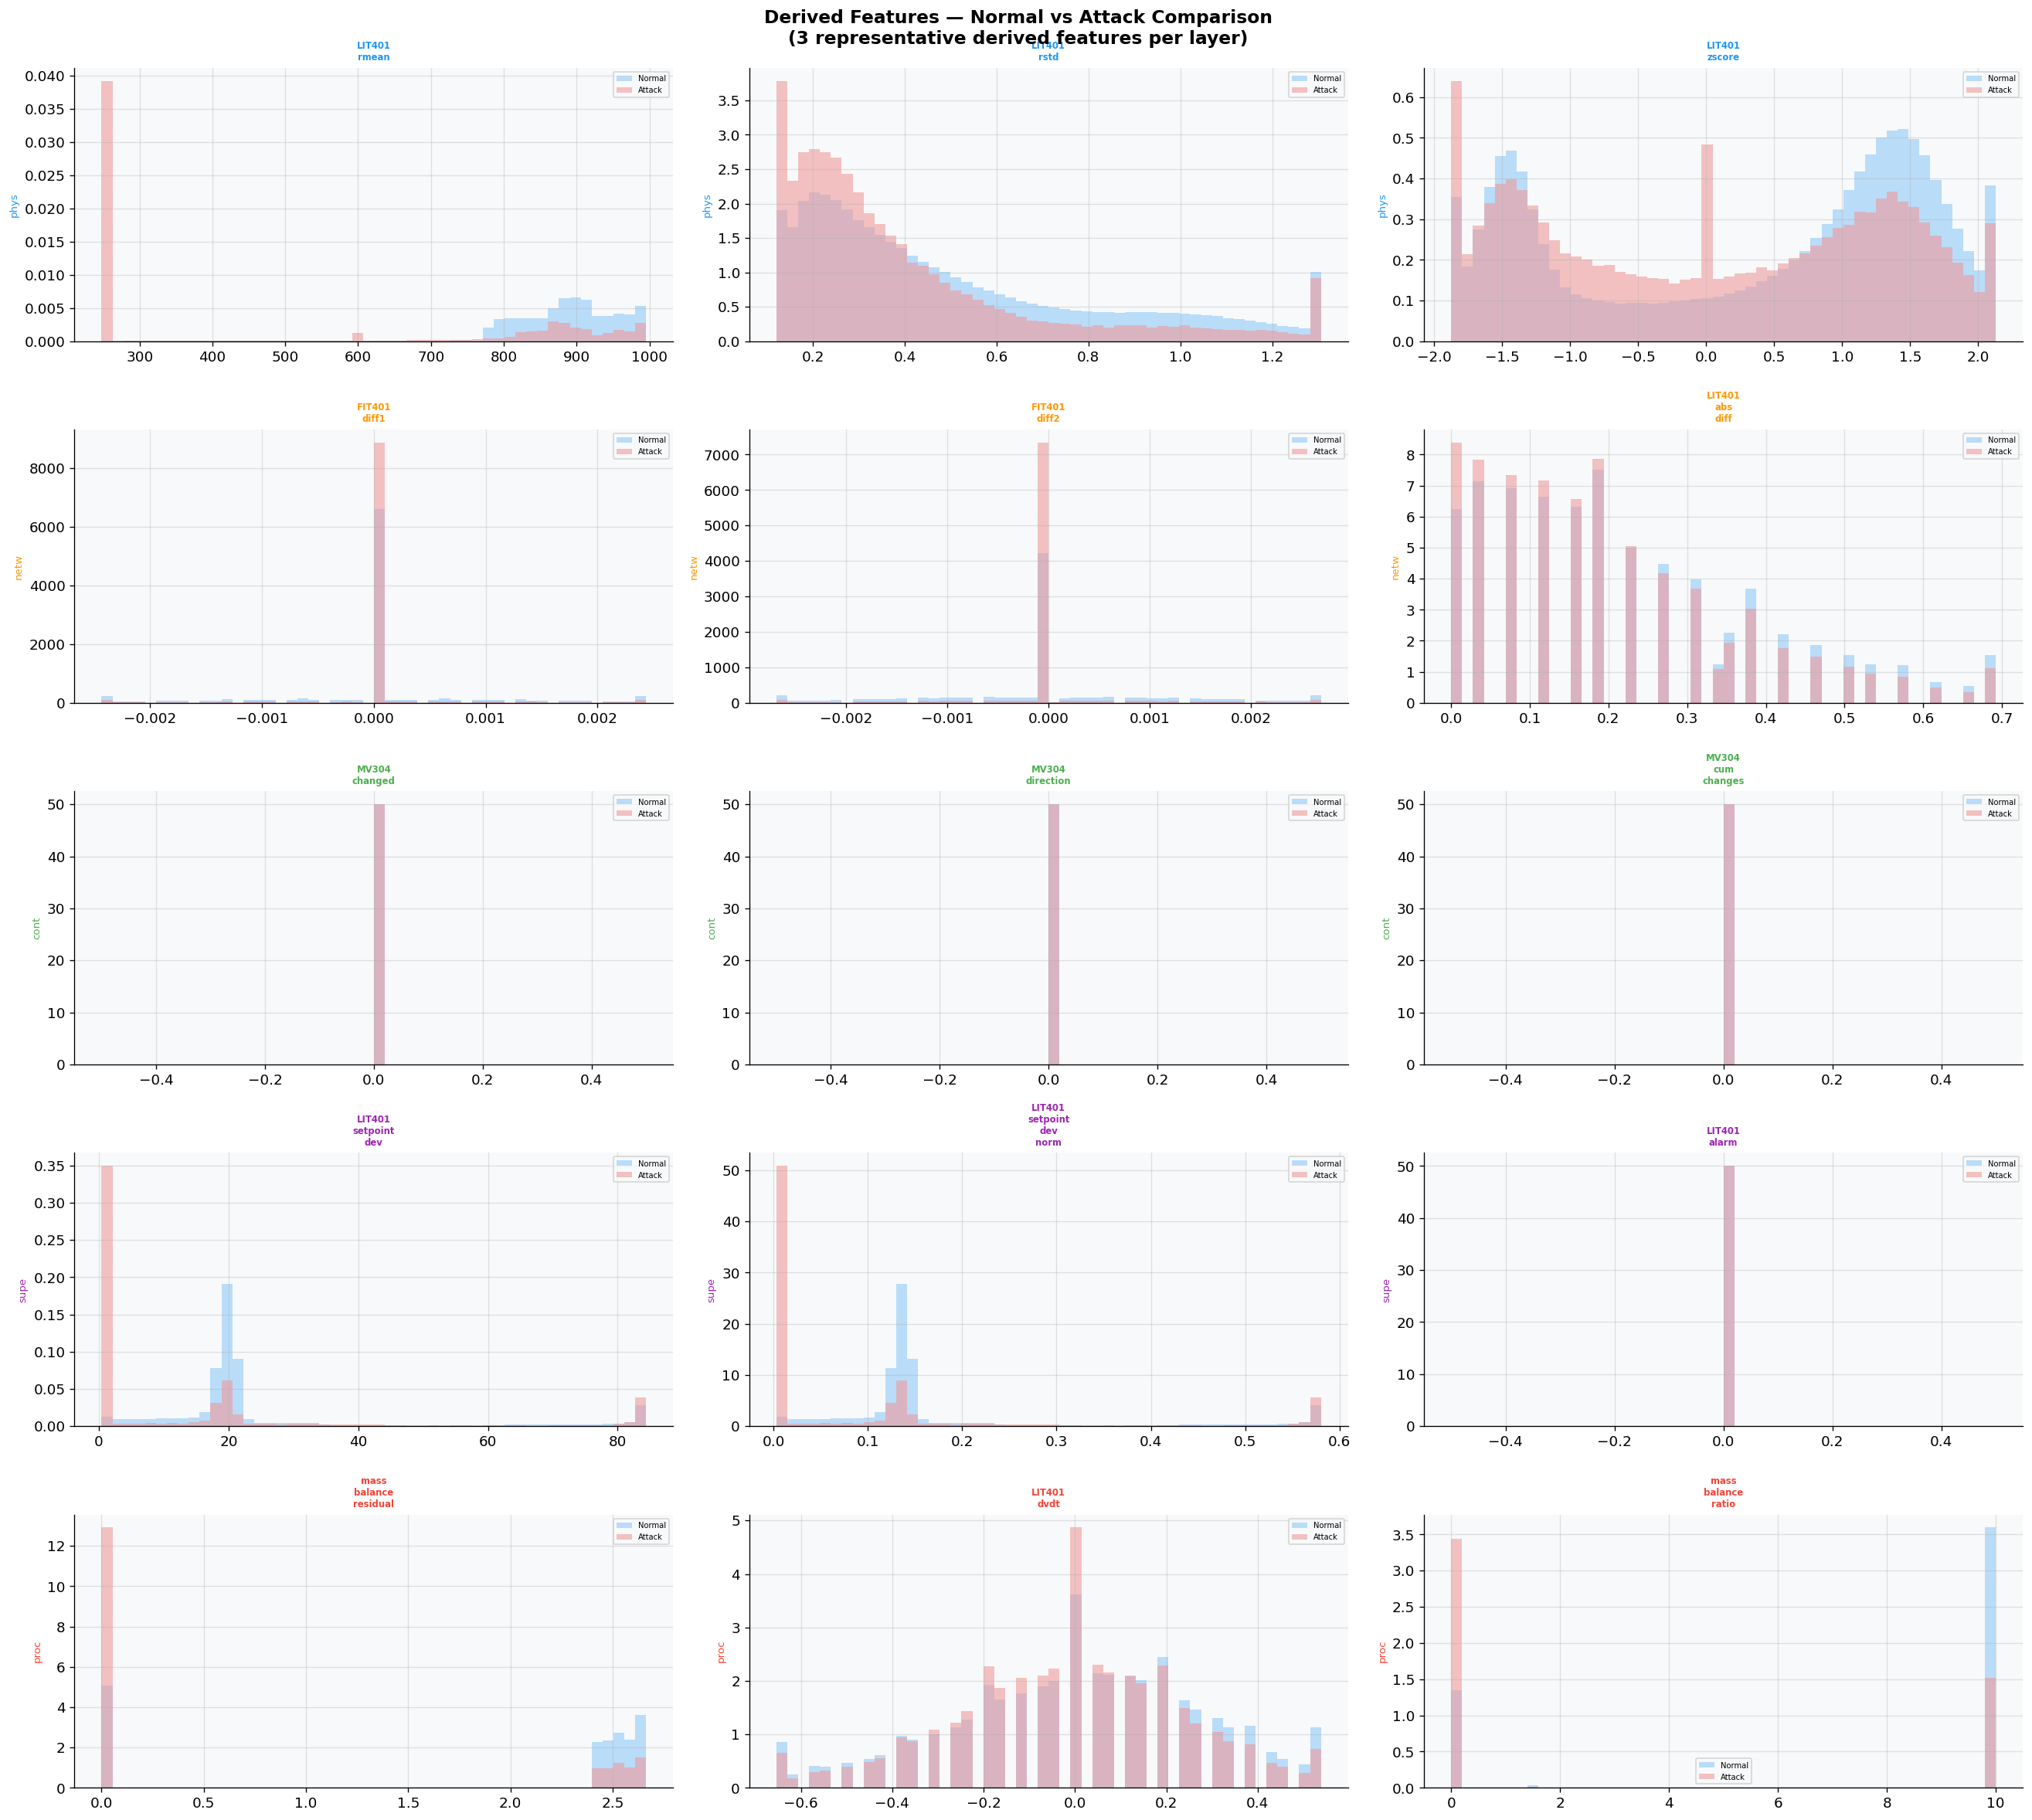

 Saved: 07_derived_features.png


In [6]:
#   CELL 6 — Visualise key derived features per layer             

fig, axes = plt.subplots(5, 3, figsize=(22, 20))
fig.suptitle('Derived Features — Normal vs Attack Comparison\n'
             '(3 representative derived features per layer)',
             fontsize=14, fontweight='bold')

derived_feature_examples = {
    'physical'    : ['LIT401_rmean',   'LIT401_rstd',   'LIT401_zscore'],
    'network'     : ['FIT401_diff1',   'FIT401_diff2',  'LIT401_abs_diff'],
    'control'     : ['MV304_changed',  'MV304_direction','MV304_cum_changes'],
    'supervisory' : ['LIT401_setpoint_dev', 'LIT401_setpoint_dev_norm',
                     'LIT401_alarm'],
    'process'     : ['mass_balance_residual', 'LIT401_dvdt',
                     'mass_balance_ratio'],
}

for row_idx, (layer, feats) in enumerate(derived_feature_examples.items()):
    color   = LAYER_COLORS[layer]
    eng_df  = engineered_layers[layer]

    for col_idx, feat in enumerate(feats):
        ax = axes[row_idx][col_idx]

        if feat not in eng_df.columns:
            ax.set_visible(False)
            continue

        data_n = eng_df[eng_df['binary_label']==0][feat].dropna().values
        data_a = eng_df[eng_df['binary_label']==1][feat].dropna().values

        if len(data_a) < 5:
            ax.set_visible(False)
            continue

        lo = np.percentile(np.concatenate([data_n, data_a]), 2)
        hi = np.percentile(np.concatenate([data_n, data_a]), 98)
        data_n = np.clip(data_n, lo, hi)
        data_a = np.clip(data_a, lo, hi)

        ax.hist(data_n, bins=50, alpha=0.6, color='#90CAF9',
                label='Normal', density=True)
        ax.hist(data_a, bins=50, alpha=0.6, color='#EF9A9A',
                label='Attack', density=True)
        ax.set_title(feat.replace('_', '\n'), fontsize=7,
                     fontweight='bold', color=color)
        ax.set_ylabel(layer[:4], fontsize=8, color=color)
        ax.legend(fontsize=6)

plt.tight_layout()
plt.savefig(f'{OUT}/figures/07_derived_features.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: 07_derived_features.png')

In [7]:
#   CELL 7 — Create train/test splits for all 5 layers            
#   Train = normal data only (for unsupervised VAE)               
#   Test  = last 20% including attacks (for evaluation)           


splits = {}

print('Creating train/test splits...')
print()

for layer in LAYER_MAP.keys():
    eng_df = engineered_layers[layer]

    # Feature columns only (no metadata)
    feat_cols = [c for c in eng_df.columns
                 if c not in ['binary_label', 'label',
                               'source', TIME_COL]]

    # Train: ALL normal rows (for training models)
    train_df = eng_df[eng_df['binary_label'] == 0].copy()

    # Test: last 20% of full dataset (contains most attacks)
    n_test  = int(len(eng_df) * 0.2)
    test_df = eng_df.iloc[-n_test:].copy()

    # Validation: 10% of train (for hyperparameter tuning)
    n_val   = int(len(train_df) * 0.1)
    val_df  = train_df.iloc[-n_val:].copy()
    train_df = train_df.iloc[:-n_val].copy()

    splits[layer] = {
        'train'     : train_df,
        'val'       : val_df,
        'test'      : test_df,
        'feat_cols' : feat_cols,
    }

    print(f'\n  {layer.upper()} LAYER')
    print(f'    Train rows   : {len(train_df):,}  '
          f'(all normal, {(train_df["binary_label"]==0).sum():,} normal)')
    print(f'    Val rows     : {len(val_df):,}  '
          f'({(val_df["binary_label"]==0).sum():,} normal)')
    print(f'    Test rows    : {len(test_df):,}  '
          f'({(test_df["binary_label"]==1).sum():,} attacks, '
          f'{test_df["binary_label"].mean()*100:.1f}% attack rate)')
    print(f'    Feature cols : {len(feat_cols)}')

print('\n All splits created')

Creating train/test splits...


  PHYSICAL LAYER
    Train rows   : 801,269  (all normal, 801,269 normal)
    Val rows     : 89,029  (89,029 normal)
    Test rows    : 188,983  (9,756 attacks, 5.2% attack rate)
    Feature cols : 100

  NETWORK LAYER
    Train rows   : 801,269  (all normal, 801,269 normal)
    Val rows     : 89,029  (89,029 normal)
    Test rows    : 188,983  (9,756 attacks, 5.2% attack rate)
    Feature cols : 36

  CONTROL LAYER
    Train rows   : 801,269  (all normal, 801,269 normal)
    Val rows     : 89,029  (89,029 normal)
    Test rows    : 188,983  (9,756 attacks, 5.2% attack rate)
    Feature cols : 104

  SUPERVISORY LAYER
    Train rows   : 801,269  (all normal, 801,269 normal)
    Val rows     : 89,029  (89,029 normal)
    Test rows    : 188,983  (9,756 attacks, 5.2% attack rate)
    Feature cols : 60

  PROCESS LAYER
    Train rows   : 801,269  (all normal, 801,269 normal)
    Val rows     : 89,029  (89,029 normal)
    Test rows    : 188,983  (9,756 attack

In [8]:
#  CELL 8  — MinMax normalise engineered features per layer 

import numpy as np

scalers = {}

print('Normalising engineered features per layer...')

for layer in LAYER_MAP.keys():
    feat_cols = splits[layer]['feat_cols']

    # ── Clean all splits before fitting ─────────────────────────
    for split_name in ['train', 'val', 'test']:
        df_ = splits[layer][split_name]

        # Replace inf and -inf with NaN first
        df_[feat_cols] = df_[feat_cols].replace(
            [np.inf, -np.inf], np.nan
        )

        # Fill NaN with column median of train set
        if split_name == 'train':
            col_medians = df_[feat_cols].median()

        df_[feat_cols] = df_[feat_cols].fillna(col_medians)

        # Final safety clip — remove any extreme outliers
        # (values beyond 1st-99th percentile of train)
        if split_name == 'train':
            col_low  = df_[feat_cols].quantile(0.001)
            col_high = df_[feat_cols].quantile(0.999)

        df_[feat_cols] = df_[feat_cols].clip(
            lower=col_low, upper=col_high, axis=1
        )

        splits[layer][split_name] = df_

    # ── Fit scaler on clean train data ───────────────────────────
    layer_scaler = MinMaxScaler()
    train_feats  = splits[layer]['train'][feat_cols].values
    layer_scaler.fit(train_feats)

    # ── Transform all splits ─────────────────────────────────────
    for split_name in ['train', 'val', 'test']:
        splits[layer][split_name][feat_cols] = layer_scaler.transform(
            splits[layer][split_name][feat_cols].values
        )

    scalers[layer] = layer_scaler
    print(f'  Yes {layer:<15} → {len(feat_cols)} features normalised')

print('\n All layers normalised — no data leakage — no inf/NaN')

Normalising engineered features per layer...
  Yes physical        → 100 features normalised
  Yes network         → 36 features normalised
  Yes control         → 104 features normalised
  Yes supervisory     → 60 features normalised
  Yes process         → 30 features normalised

 All layers normalised — no data leakage — no inf/NaN


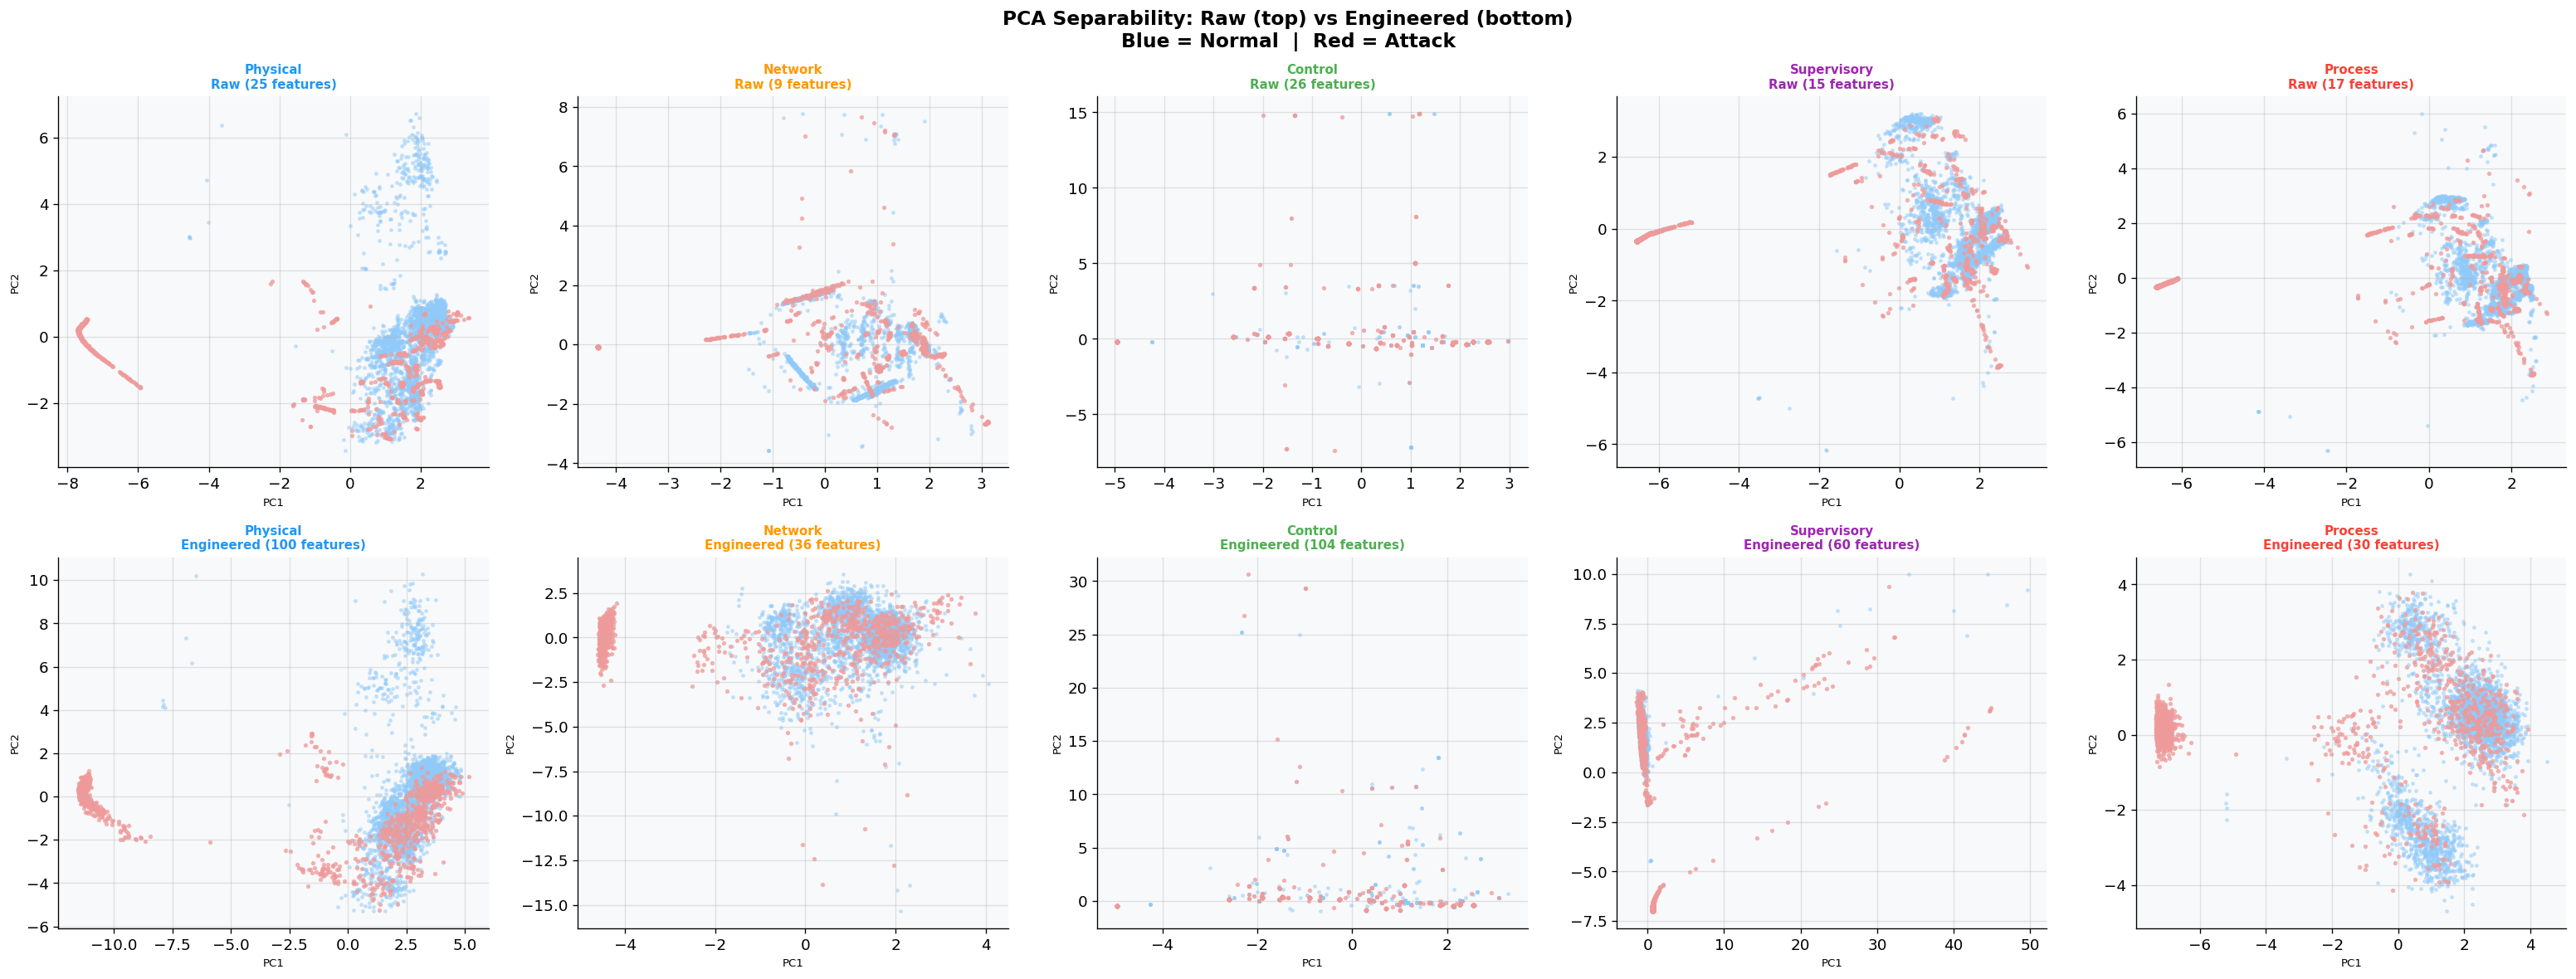

 Saved: 08_pca_raw_vs_engineered.png


In [9]:
#   CELL 9 — PCA raw vs engineered                         

from sklearn.decomposition import PCA

def clean_df(df_, ref_df=None):
    """Replace inf/NaN, clip outliers. ref_df used for median/quantile."""
    src = ref_df if ref_df is not None else df_
    num_cols = df_.select_dtypes(include=[np.number]).columns.tolist()
    df_ = df_.copy()
    df_[num_cols] = df_[num_cols].replace([np.inf, -np.inf], np.nan)
    medians = src[num_cols].replace([np.inf, -np.inf], np.nan).median()
    df_[num_cols] = df_[num_cols].fillna(medians)
    lo = src[num_cols].replace([np.inf, -np.inf], np.nan).quantile(0.001)
    hi = src[num_cols].replace([np.inf, -np.inf], np.nan).quantile(0.999)
    df_[num_cols] = df_[num_cols].clip(lower=lo, upper=hi, axis=1)
    return df_

# Clean engineered_layers in place
for layer in engineered_layers:
    engineered_layers[layer] = clean_df(engineered_layers[layer])

fig, axes = plt.subplots(2, 5, figsize=(26, 10))
fig.suptitle('PCA Separability: Raw (top) vs Engineered (bottom)\n'
             'Blue = Normal  |  Red = Attack',
             fontsize=14, fontweight='bold')

n_sample = 3000

for col_idx, layer in enumerate(LAYER_MAP.keys()):
    color = LAYER_COLORS[layer]

    # ── Row 1: Raw features ──────────────────────────────────────
    raw_view  = router.get_layer(layer)
    raw_feats = [c for c in raw_view.columns
                 if c not in ['binary_label', 'label', 'source', TIME_COL]]

    n_n = min(n_sample, (raw_view['binary_label']==0).sum())
    n_a = min(n_sample//2, int((raw_view['binary_label']==1).sum()))
    sn  = raw_view[raw_view['binary_label']==0].sample(n_n, random_state=42)
    sa  = raw_view[raw_view['binary_label']==1].sample(n_a, random_state=42)
    s   = pd.concat([sn, sa]).reset_index(drop=True)
    s   = clean_df(s)

    X_raw = PCA(2, random_state=42).fit_transform(
        StandardScaler().fit_transform(s[raw_feats].values))
    lbl   = s['binary_label'].values

    axes[0][col_idx].scatter(X_raw[lbl==0,0], X_raw[lbl==0,1],
                              c='#90CAF9', s=4, alpha=0.4, rasterized=True)
    axes[0][col_idx].scatter(X_raw[lbl==1,0], X_raw[lbl==1,1],
                              c='#EF9A9A', s=5, alpha=0.65, rasterized=True)
    axes[0][col_idx].set_title(
        f'{layer.capitalize()}\nRaw ({len(raw_feats)} features)',
        fontsize=9, fontweight='bold', color=color)
    axes[0][col_idx].set_xlabel('PC1', fontsize=8)
    axes[0][col_idx].set_ylabel('PC2', fontsize=8)

    # ── Row 2: Engineered features ───────────────────────────────
    eng_view  = engineered_layers[layer]
    eng_feats = [c for c in eng_view.columns
                 if c not in ['binary_label', 'label', 'source', TIME_COL]]

    n_n2 = min(n_sample, (eng_view['binary_label']==0).sum())
    n_a2 = min(n_sample//2, int((eng_view['binary_label']==1).sum()))
    sn2  = eng_view[eng_view['binary_label']==0].sample(n_n2, random_state=42)
    sa2  = eng_view[eng_view['binary_label']==1].sample(n_a2, random_state=42)
    s2   = pd.concat([sn2, sa2]).reset_index(drop=True)
    s2   = clean_df(s2)

    X_eng = PCA(2, random_state=42).fit_transform(
        StandardScaler().fit_transform(s2[eng_feats].values))
    lbl2  = s2['binary_label'].values

    axes[1][col_idx].scatter(X_eng[lbl2==0,0], X_eng[lbl2==0,1],
                              c='#90CAF9', s=4, alpha=0.4, rasterized=True)
    axes[1][col_idx].scatter(X_eng[lbl2==1,0], X_eng[lbl2==1,1],
                              c='#EF9A9A', s=5, alpha=0.65, rasterized=True)
    axes[1][col_idx].set_title(
        f'{layer.capitalize()}\nEngineered ({len(eng_feats)} features)',
        fontsize=9, fontweight='bold', color=color)
    axes[1][col_idx].set_xlabel('PC1', fontsize=8)
    axes[1][col_idx].set_ylabel('PC2', fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUT}/figures/08_pca_raw_vs_engineered.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: 08_pca_raw_vs_engineered.png')

In [10]:
#   CELL 10 — Save all Phase 2 outputs                     
P = f'{OUT}/processed'

# 1. Save engineered layer CSVs (already cleaned)
for layer, eng_df in engineered_layers.items():
    path = f'{P}/layer_{layer}_engineered.csv'
    eng_df.to_csv(path, index=False)
    print(f' layer_{layer}_engineered.csv  '
          f'→ {eng_df.shape[0]:,} rows × {eng_df.shape[1]} cols')

# 2. Save train/val/test splits per layer
for layer in LAYER_MAP.keys():
    for split_name in ['train', 'val', 'test']:
        path = f'{P}/layer_{layer}_{split_name}.csv'
        splits[layer][split_name].to_csv(path, index=False)
print(' Saved train/val/test splits for all 5 layers (15 files)')

# 3. Save per-layer scalers
with open(f'{P}/layer_scalers.pkl', 'wb') as f:
    pickle.dump(scalers, f)
print(' layer_scalers.pkl  → per-layer MinMaxScalers')

# 4. Save feature counts
with open(f'{P}/layer_feature_counts.json', 'w') as f:
    json.dump(layer_feature_counts, f, indent=2)
print(' layer_feature_counts.json')

# 5. Save Phase 2 config
p2_config = {
    'phase'          : 2,
    'window_size'    : engineer.window,
    'layers'         : list(LAYER_MAP.keys()),
    'feature_counts' : layer_feature_counts,
    'split_ratios'   : {'train': 0.7, 'val': 0.1, 'test': 0.2},
    'split_sizes'    : {
        layer: {
            s: len(splits[layer][s])
            for s in ['train', 'val', 'test']
        }
        for layer in LAYER_MAP.keys()
    },
}
with open(f'{P}/phase2_config.json', 'w') as f:
    json.dump(p2_config, f, indent=2)
print(' phase2_config.json  → config for Phase 3 models')

print()
print()
print('  PHASE 2 COMPLETE')
print()
for layer in LAYER_MAP.keys():
    fc = layer_feature_counts[layer]
    print(f'  {layer:<15} '
          f'orig={fc["original"]:>3}  '
          f'derived={fc["derived"]:>4}  '
          f'total={fc["total"]:>4}  '
          f'train={len(splits[layer]["train"]):>7,}  '
          f'test={len(splits[layer]["test"]):>7,}')
print()
print(f'  Figures saved  : 2')
print(f'  Files saved    : 19')
print()

 layer_physical_engineered.csv  → 944,919 rows × 104 cols
 layer_network_engineered.csv  → 944,919 rows × 40 cols
 layer_control_engineered.csv  → 944,919 rows × 108 cols
 layer_supervisory_engineered.csv  → 944,919 rows × 64 cols
 layer_process_engineered.csv  → 944,919 rows × 34 cols
 Saved train/val/test splits for all 5 layers (15 files)
 layer_scalers.pkl  → per-layer MinMaxScalers
 layer_feature_counts.json
 phase2_config.json  → config for Phase 3 models


  PHASE 2 COMPLETE

  physical        orig= 25  derived=  75  total= 100  train=801,269  test=188,983
  network         orig=  9  derived=  27  total=  36  train=801,269  test=188,983
  control         orig= 26  derived=  78  total= 104  train=801,269  test=188,983
  supervisory     orig= 15  derived=  45  total=  60  train=801,269  test=188,983
  process         orig= 17  derived=  13  total=  30  train=801,269  test=188,983

  Figures saved  : 2
  Files saved    : 19

